In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Helper functions

In [3]:
def aggregate_experiment_results(df):
    """
    Aggregate experiment results across repeats.

    Parameters
    ----------
    df : pandas.DataFrame
        Experiment results containing one row per repeat.
    """

    group_cols = ["scenario", "model_key", "n", "p", "s2"]

    # If status is available, only aggregate successfully completed runs.
    data = df.copy()
    if "status" in data.columns:
        data = data[data["status"] == "complete"].copy()

    methods = [
        "raw_local",
        "raw_global_max",
        "raw_global_se",
        "logml_local",
        "logml_global_max",
        "logml_global_se",
    ]

    grouped = data.groupby(group_cols, dropna=False, sort=False)

    # Start summary table with the number of completed repeats.
    summary_df = (
        grouped.size()
        .rename("n_repeats")
        .reset_index()
    )

    for method in methods:
        for metric in ["precision", "recall", "f1"]:
            col = f"{metric}_{method}"

            means = grouped[col].mean()
            ses = grouped[col].sem()

            metric_summary = pd.DataFrame({
                f"{col}_mean": means,
                f"{col}_se": ses,
            }).reset_index()

            summary_df = summary_df.merge(
                metric_summary,
                on=group_cols,
                how="left",
            )

        # r_miss is binary, so its mean is the proportion of repeats
        # for which r_miss == 1.
        r_miss_col = f"r_miss_{method}"

        r_miss = (
            grouped[r_miss_col]
            .apply(lambda x: (x == 1).mean())
            .rename(f"{r_miss_col}_rate")
            .reset_index()
        )

        summary_df = summary_df.merge(
            r_miss,
            on=group_cols,
            how="left",
        )

    # Build long-format n_selected frequency table.
    n_selected_parts = []

    for method in methods:
        col = f"n_selected_{method}"

        counts = (
            data
            .groupby(group_cols + [col], dropna=False)
            .size()
            .rename("count")
            .reset_index()
            .rename(columns={col: "n_selected"})
        )

        counts["method"] = method

        counts = counts[
            group_cols
            + ["method", "n_selected", "count"]
        ]

        n_selected_parts.append(counts)

    n_selected_df = pd.concat(
        n_selected_parts,
        ignore_index=True,
    )

    n_selected_df = n_selected_df.sort_values(
        group_cols + ["method", "n_selected"],
        ignore_index=True,
    )

    return summary_df, n_selected_df

In [4]:
def display_summary_table(summary_df, method, output_path=None):
    if method not in {"local", "global_max", "global_se"}:
        raise ValueError("method must be 'local', 'global_max', or 'global_se'.")

    df = summary_df.copy()
    out = df[["n", "p", "s2"]].copy()
    styles = pd.DataFrame("", index=df.index, columns=[
        "n", "p", "s2",
        "Precision Raw", "Precision LogML",
        "Recall Raw", "Recall LogML",
        "F1 Raw", "F1 LogML",
        "r_miss Raw", "r_miss LogML"
    ])

    for metric, label in [("precision", "Precision"), ("recall", "Recall"), ("f1", "F1")]:
        r, l = f"{metric}_raw_{method}", f"{metric}_logml_{method}"
        out[f"{label} Raw"] = df.apply(lambda x: f"{x[r+'_mean']:.3f} ({x[r+'_se']:.2f})", axis=1)
        out[f"{label} LogML"] = df.apply(lambda x: f"{x[l+'_mean']:.3f} ({x[l+'_se']:.2f})", axis=1)

        styles.loc[df[r+"_mean"] > df[l+"_mean"], f"{label} Raw"] = "background-color: #e88b8b; color: black"
        styles.loc[df[l+"_mean"] > df[r+"_mean"], f"{label} LogML"] = "background-color: #8fd18f; color: black"


    r, l = f"r_miss_raw_{method}_rate", f"r_miss_logml_{method}_rate"
    out["r_miss Raw"] = df[r].map(lambda x: f"{x:.0%}")
    out["r_miss LogML"] = df[l].map(lambda x: f"{x:.0%}")

    styles.loc[df[r] < df[l], "r_miss Raw"] = "background-color: #e88b8b; color: black"
    styles.loc[df[l] < df[r], "r_miss LogML"] = "background-color: #8fd18f; color: black"

    if output_path is not None:
        out.to_csv(output_path, index=False)

    display(out.style.apply(lambda _: styles, axis=None))

In [5]:
def plot_n_selected_histograms(n_selected_df, true_n_selected):
    params = list(
        n_selected_df[["n", "p", "s2"]]
        .drop_duplicates()
        .sort_values(["n", "p", "s2"])
        .itertuples(index=False, name=None)
    )

    fig, axes = plt.subplots(
        2, len(params),
        figsize=(6 * len(params), 7),
        sharey=True,
        squeeze=False
    )

    methods = [
        ("local", "Local", ""),
        ("global_se", "Global SE", "///"),
        ("global_max", "Global Max", "...")
    ]
    width = 0.25

    def make_bins(values, true_n):
        values = sorted(set(int(v) for v in values) | {int(true_n)})
        vmin, vmax = min(values), max(values)

        if vmax - vmin <= 10:
            labels = values
            return labels, labels, None

        lo = max(0, int(true_n) - 5)
        hi = int(true_n) + 5

        labels = []
        if vmin < lo:
            labels.append(f"<{lo}")
        labels.extend(list(range(lo, hi + 1)))
        if vmax > hi:
            labels.append(f">{hi}")

        return labels, list(range(lo, hi + 1)), (lo, hi)

    def collapse_counts(counts, labels, middle_vals, tails):
        out = []
        lo, hi = tails if tails is not None else (None, None)

        for lab in labels:
            if isinstance(lab, str) and lab.startswith("<"):
                out.append(sum(c for v, c in counts.items() if v < lo))
            elif isinstance(lab, str) and lab.startswith(">"):
                out.append(sum(c for v, c in counts.items() if v > hi))
            else:
                out.append(counts.get(lab, 0))
        return out

    for col, (n, p, s2) in enumerate(params):
        d = n_selected_df[
            (n_selected_df["n"] == n) &
            (n_selected_df["p"] == p) &
            (n_selected_df["s2"] == s2)
        ]

        labels, middle_vals, tails = make_bins(d["n_selected"], true_n_selected)
        x = np.arange(len(labels))
        true_pos = labels.index(true_n_selected)

        for row, weight in enumerate(["raw", "logml"]):
            ax = axes[row, col]
            dw = d[d["method"].str.startswith(weight + "_")]

            ax.axvspan(true_pos - 0.5, true_pos + 0.5, color="0.9", zorder=0)

            for i, (suffix, legend_label, hatch) in enumerate(methods):
                dm = dw[dw["method"] == f"{weight}_{suffix}"]
                counts = dm.groupby("n_selected")["count"].sum().to_dict()

                if tails is None:
                    y = [counts.get(v, 0) for v in labels]
                else:
                    y = collapse_counts(counts, labels, middle_vals, tails)

                ax.bar(
                    x + (i - 1) * width,
                    y,
                    width,
                    label=legend_label,
                    facecolor="white",
                    edgecolor="black",
                    hatch=hatch
                )

            ax.set_xticks(x)
            ax.set_xticklabels(labels)

            for tick, lab in zip(ax.get_xticklabels(), labels):
                if lab == true_n_selected:
                    tick.set_fontweight("bold")

            if row == 0:
                ax.set_title(rf"$n={n},\ p={p},\ \sigma^2={s2}$")
            else:
                ax.set_xlabel("Number selected")

            if col == 0:
                ax.set_ylabel(f"{'Raw' if row == 0 else 'LogML'}\nCount")

    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="upper center", ncol=3, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

In [6]:
def display_n_selected_summary(n_selected_df, true_n_selected, output_path=None):
    rows = []

    for (n, p, s2, method), d in n_selected_df.groupby(["n", "p", "s2", "method"]):
        total = d["count"].sum()
        mean = (d["n_selected"] * d["count"]).sum() / total
        exact = d.loc[d["n_selected"] == true_n_selected, "count"].sum() / total
        under = d.loc[d["n_selected"] < true_n_selected, "count"].sum() / total
        over = d.loc[d["n_selected"] > true_n_selected, "count"].sum() / total
        excess = (np.maximum(d["n_selected"] - true_n_selected, 0) * d["count"]).sum() / total

        weight, threshold = method.split("_", 1)
        rows.append([n, p, s2, threshold, weight, mean, exact, under, over, excess])

    x = pd.DataFrame(rows, columns=[
        "n", "p", "s2", "method", "weight",
        "mean", "exact", "under", "over", "excess"
    ])

    labels = {"local": "Local", "global_se": "Global SE", "global_max": "Global Max"}
    order = ["local", "global_se", "global_max"]
    out = []

    for keys, d in x.groupby(["n", "p", "s2", "method"], sort=False):
        vals = {r["weight"]: r for _, r in d.iterrows()}
        out.append([
            *keys[:3], labels[keys[3]],
            f'{vals["raw"]["mean"]:.2f}', f'{vals["logml"]["mean"]:.2f}',
            f'{vals["raw"]["exact"]:.0%}', f'{vals["logml"]["exact"]:.0%}',
            f'{vals["raw"]["under"]:.0%}', f'{vals["logml"]["under"]:.0%}',
            f'{vals["raw"]["over"]:.0%}', f'{vals["logml"]["over"]:.0%}',
            f'{vals["raw"]["excess"]:.2f}', f'{vals["logml"]["excess"]:.2f}'
        ])

    out = pd.DataFrame(out, columns=[
        "n", "p", "s2", "Method",
        "Mean Raw", "Mean LogML",
        "Exact Raw", "Exact LogML",
        "Under Raw", "Under LogML",
        "Over Raw", "Over LogML",
        "Mean Excess Raw", "Mean Excess LogML"
    ])

    out["Method"] = pd.Categorical(out["Method"], [labels[m] for m in order], ordered=True)
    out = out.sort_values(["n", "p", "s2", "Method"]).reset_index(drop=True)

    if output_path is not None:
        out.to_csv(output_path, index=False)

    display(out)

In [7]:
def aggregate_hyperparameter_results(df):
    data = df[df["status"].eq("complete")].copy() if "status" in df else df.copy()
    groups = ["scenario", "model_key", "n", "p", "s2", "config_id",
              "varied_parameter", "m", "alpha", "beta", "k"]
    methods = ["raw_local", "raw_global_max", "raw_global_se",
               "logml_local", "logml_global_max", "logml_global_se"]

    g = data.groupby(groups, dropna=False, sort=False)
    out = g.size().rename("n_repeats").reset_index()

    for method in methods:
        for metric in ["precision", "recall", "f1"]:
            col = f"{metric}_{method}"
            x = g[col].agg(["mean", "sem"]).rename(
                columns={"mean": f"{col}_mean", "sem": f"{col}_se"})
            out = out.merge(x.reset_index(), on=groups)

        col = f"r_miss_{method}"
        x = g[col].apply(lambda s: (s == 1).mean()).rename(f"{col}_rate")
        out = out.merge(x.reset_index(), on=groups)

    return out

In [8]:
def display_hyperparameter_summary(summary_df, method, output_path=None):
    if method not in {"local", "global_se", "global_max"}:
        raise ValueError("method must be 'local', 'global_se', or 'global_max'.")

    ref = summary_df[summary_df["config_id"].eq("reference")]
    blocks = []

    for param in ["m", "beta", "k"]:
        d = pd.concat([summary_df[summary_df["varied_parameter"].eq(param)], ref])
        d = d.sort_values(param).copy()
        d["Parameter"] = {"m": "m", "beta": "β", "k": "k"}[param]
        d["Value"] = d[param]
        d["_reference"] = d["config_id"].eq("reference")
        blocks.append(d)

    d = pd.concat(blocks, ignore_index=True)
    out = d[["Parameter", "Value"]].copy()

    cols = ["Parameter", "Value",
            "Precision Raw", "Precision LogML",
            "Recall Raw", "Recall LogML",
            "F1 Raw", "F1 LogML",
            "r_miss Raw", "r_miss LogML"]
    styles = pd.DataFrame("", index=d.index, columns=cols)

    for metric, label in [("precision", "Precision"), ("recall", "Recall"), ("f1", "F1")]:
        r, l = f"{metric}_raw_{method}", f"{metric}_logml_{method}"
        out[f"{label} Raw"] = d.apply(lambda x: f"{x[r+'_mean']:.2f} ({x[r+'_se']:.2f})", axis=1)
        out[f"{label} LogML"] = d.apply(lambda x: f"{x[l+'_mean']:.2f} ({x[l+'_se']:.2f})", axis=1)

        styles.loc[d[r+"_mean"] > d[l+"_mean"], f"{label} Raw"] = \
            "background-color: #e88b8b; color: black"
        styles.loc[d[l+"_mean"] > d[r+"_mean"], f"{label} LogML"] = \
            "background-color: #8fd18f; color: black"

    r, l = f"r_miss_raw_{method}_rate", f"r_miss_logml_{method}_rate"
    out["r_miss Raw"] = d[r].map(lambda x: f"{x:.0%}")
    out["r_miss LogML"] = d[l].map(lambda x: f"{x:.0%}")

    styles.loc[d[r] < d[l], "r_miss Raw"] = "background-color: #e88b8b; color: black"
    styles.loc[d[l] < d[r], "r_miss LogML"] = "background-color: #8fd18f; color: black"
    styles.loc[d["_reference"], "Value"] = "font-weight: bold"

    if output_path is not None:
        out.to_csv(output_path, index=False)

    display(out.style.apply(lambda _: styles, axis=None))

In [30]:
def aggregate_paired_hyperparameter_results(df):
    data = df[df["status"].eq("complete")].copy() if "status" in df else df.copy()
    keys = ["scenario", "model_key", "n", "p", "s2", "repeat", "seed"]
    stats = ["precision", "recall", "f1", "r_miss", "n_selected"]
    methods = ["raw_local", "raw_global_se", "raw_global_max",
               "logml_local", "logml_global_se", "logml_global_max"]
    cols = [f"{s}_{m}" for s in stats for m in methods]

    ref = data[data["config_id"].eq("reference")][keys + ["m", "beta", "k"] + cols]
    alt = data[~data["config_id"].eq("reference")].copy()
    paired = alt.merge(ref, on=keys, suffixes=("", "_ref"), validate="many_to_one")

    paired["value"] = paired.apply(lambda r: r[r["varied_parameter"]], axis=1)
    paired["reference_value"] = paired.apply(
        lambda r: r[f'{r["varied_parameter"]}_ref'], axis=1)

    for c in cols:
        paired[f"delta_{c}"] = paired[c] - paired[f"{c}_ref"]

    groups = ["scenario", "model_key", "n", "p", "s2", "config_id",
              "varied_parameter", "value", "reference_value"]
    g = paired.groupby(groups, dropna=False, sort=False)
    out = g.size().rename("n_pairs").reset_index()

    for c in [f"delta_{c}" for c in cols]:
        x = g[c].agg(["mean", "sem"]).rename(
            columns={"mean": f"{c}_mean", "sem": f"{c}_se"})
        out = out.merge(x.reset_index(), on=groups)

    return out

In [31]:
def display_paired_summary(paired_df, method, output_path=None):
    if method not in {"local", "global_se", "global_max"}:
        raise ValueError("Invalid method.")

    d = paired_df.copy()
    d["Parameter"] = d["varied_parameter"].map({"m": "m", "beta": "β", "k": "k"})
    d["Value"] = d["value"].map(lambda x: f"{x:g}")
    d["_ord"] = d["varied_parameter"].map({"m": 0, "beta": 1, "k": 2})
    d = d.sort_values(["_ord", "value"])

    out = d[["Parameter", "Value"]].reset_index(drop=True)

    for metric, label in [("precision", "Δ Precision"), ("recall", "Δ Recall"),
                          ("f1", "Δ F1"), ("n_selected", "Δ Selected")]:
        for weight, name in [("raw", "Raw"), ("logml", "LogML")]:
            c = f"delta_{metric}_{weight}_{method}"
            out[f"{label} {name}"] = [
                f"{m:+.2f} ({s:.2f})" for m, s in zip(d[c+"_mean"], d[c+"_se"])
            ]

    for weight, name in [("raw", "Raw"), ("logml", "LogML")]:
        c = f"delta_r_miss_{weight}_{method}"
        out[f"Δ r_miss {name}"] = [
            f"{100*m:+.1f} pp ({100*s:.1f})"
            for m, s in zip(d[c+"_mean"], d[c+"_se"])
        ]

    if output_path is not None:
        out.to_csv(output_path, index=False)

    display(out)

In [32]:
def plot_paired_sensitivity(paired_df, method, output_path=None):
    params = [("m", r"$m$"), ("beta", r"$\beta$"), ("k", r"$k$")]
    metrics = [("precision", "Precision", 1), ("recall", "Recall", 1),
               ("f1", "F1", 1), ("r_miss", r"$r_{\rm miss}$ (pp)", 100),
               ("n_selected", "Number selected", 1)]

    fig, axes = plt.subplots(5, 3, figsize=(12, 12), sharey="row")

    for j, (param, title) in enumerate(params):
        d = paired_df[paired_df["varied_parameter"].eq(param)].sort_values("value")
        ref = float(d["reference_value"].iloc[0])

        for i, (metric, ylabel, scale) in enumerate(metrics):
            ax = axes[i, j]

            for weight, label, marker, ls in [
                ("raw", "Raw", "o", "-"), ("logml", "LogML", "s", "--")
            ]:
                c = f"delta_{metric}_{weight}_{method}"
                x = np.r_[d["value"].to_numpy(float), ref]
                y = np.r_[d[c+"_mean"].to_numpy(float) * scale, 0]
                se = np.r_[d[c+"_se"].to_numpy(float) * scale, 0]
                order = np.argsort(x)

                ax.errorbar(x[order], y[order], yerr=se[order],
                            marker=marker, linestyle=ls, color="black",
                            markerfacecolor="white", capsize=3, label=label)

            ax.axhline(0, color="black", linewidth=.8, alpha=.5)
            ticks = sorted(set(d["value"].tolist() + [ref]))
            ax.set_xticks(ticks)

            for tick, value in zip(ax.get_xticklabels(), ticks):
                if value == ref:
                    tick.set_fontweight("bold")

            if i == 0:
                ax.set_title(title)
            if j == 0:
                ax.set_ylabel(r"$\Delta$ " + ylabel)
            if i == 4:
                ax.set_xlabel("Hyperparameter value")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, .97])

    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight")

    plt.show()

In [41]:
def aggregate_hyperparameter_sensitivity(df):
    data = df[df["status"].eq("complete")].copy() if "status" in df else df.copy()
    keys = ["scenario", "model_key", "n", "p", "s2", "repeat", "seed"]
    stats = ["precision", "recall", "f1", "r_miss", "n_selected"]
    methods = ["local", "global_se", "global_max"]

    ref = data[data["config_id"].eq("reference")]
    alt = data[~data["config_id"].eq("reference")].copy()
    paired = alt.merge(ref, on=keys, suffixes=("", "_ref"), validate="many_to_one")

    paired["value"] = paired.apply(lambda r: r[r["varied_parameter"]], axis=1)
    paired["reference_value"] = paired.apply(
        lambda r: r[f'{r["varied_parameter"]}_ref'], axis=1)

    for stat in stats:
        for method in methods:
            for weight in ["raw", "logml"]:
                c = f"{stat}_{weight}_{method}"
                paired[f"abs_delta_{c}"] = (paired[c] - paired[f"{c}_ref"]).abs()

            paired[f"sens_diff_{stat}_{method}"] = (
                paired[f"abs_delta_{stat}_logml_{method}"] -
                paired[f"abs_delta_{stat}_raw_{method}"]
            )

    groups = ["scenario", "model_key", "n", "p", "s2", "config_id",
              "varied_parameter", "value", "reference_value"]
    g = paired.groupby(groups, dropna=False, sort=False)
    out = g.size().rename("n_pairs").reset_index()

    cols = [c for c in paired if c.startswith(("abs_delta_", "sens_diff_"))]
    for c in cols:
        x = g[c].agg(["mean", "sem"]).rename(
            columns={"mean": f"{c}_mean", "sem": f"{c}_se"})
        out = out.merge(x.reset_index(), on=groups)

    return out

In [42]:
def display_sensitivity_summary(sensitivity_df, method, metric="f1", output_path=None):
    if method not in {"local", "global_se", "global_max"}:
        raise ValueError("Invalid method.")
    if metric not in {"precision", "recall", "f1", "r_miss", "n_selected"}:
        raise ValueError("Invalid metric.")

    d = sensitivity_df.copy()
    d["Parameter"] = d["varied_parameter"].map({"m": "m", "beta": "β", "k": "k"})
    d["Value"] = d["value"].map(lambda x: f"{x:g}")
    d["_ord"] = d["varied_parameter"].map({"m": 0, "beta": 1, "k": 2})
    d = d.sort_values(["_ord", "value"])

    scale = 100 if metric == "r_miss" else 1
    suffix = " pp" if metric == "r_miss" else ""
    r = f"abs_delta_{metric}_raw_{method}"
    l = f"abs_delta_{metric}_logml_{method}"
    q = f"sens_diff_{metric}_{method}"

    out = d[["Parameter", "Value"]].reset_index(drop=True)
    out["|Δ| Raw"] = [f"{scale*m:.2f} ({scale*s:.2f}){suffix}"
                      for m, s in zip(d[r+"_mean"], d[r+"_se"])]
    out["|Δ| LogML"] = [f"{scale*m:.2f} ({scale*s:.2f}){suffix}"
                        for m, s in zip(d[l+"_mean"], d[l+"_se"])]
    out["LogML − Raw"] = [f"{scale*m:+.2f} ({scale*s:.2f}){suffix}"
                          for m, s in zip(d[q+"_mean"], d[q+"_se"])]

    if output_path is not None:
        out.to_csv(output_path, index=False)

    display(out)

In [43]:
def plot_hyperparameter_sensitivity(sensitivity_df, method, output_path=None):
    params = [("m", r"$m$"), ("beta", r"$\beta$"), ("k", r"$k$")]
    metrics = [("precision", "Precision", 1), ("recall", "Recall", 1),
               ("f1", "F1", 1), ("r_miss", r"$r_{\rm miss}$ (pp)", 100),
               ("n_selected", "Number selected", 1)]

    fig, axes = plt.subplots(5, 3, figsize=(12, 12), sharey="row")

    for j, (param, title) in enumerate(params):
        d = sensitivity_df[sensitivity_df["varied_parameter"].eq(param)].sort_values("value")
        ref = float(d["reference_value"].iloc[0])

        for i, (metric, ylabel, scale) in enumerate(metrics):
            ax = axes[i, j]

            for weight, label, marker, ls in [
                ("raw", "Raw", "o", "-"), ("logml", "LogML", "s", "--")
            ]:
                c = f"abs_delta_{metric}_{weight}_{method}"
                x = np.r_[d["value"].to_numpy(float), ref]
                y = np.r_[d[c+"_mean"].to_numpy(float) * scale, 0]
                se = np.r_[d[c+"_se"].to_numpy(float) * scale, 0]
                order = np.argsort(x)

                ax.errorbar(x[order], y[order], yerr=se[order],
                            marker=marker, linestyle=ls, color="black",
                            markerfacecolor="white", capsize=3, label=label)

            ticks = sorted(set(d["value"].tolist() + [ref]))
            ax.set_xticks(ticks)

            for tick, value in zip(ax.get_xticklabels(), ticks):
                if value == ref:
                    tick.set_fontweight("bold")

            ax.set_ylim(bottom=0)

            if i == 0:
                ax.set_title(title)
            if j == 0:
                ax.set_ylabel(r"Mean $|\Delta|$ " + ylabel)
            if i == 4:
                ax.set_xlabel("Hyperparameter value")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, .97])

    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight")

    plt.show()

## Experimental Results

In [15]:
output_path = "results/export_tables/"

### Continuous Predictors and Continuous Response

In [11]:
cc1_full = pd.read_csv("results/cc1_002.csv")
cc1_summary, cc1_selected = aggregate_experiment_results(cc1_full)
cc1_summary_out = None if output_path == None else "cc1_summary.csv"
cc1_selected_out = None if output_path == None else "cc1_selected.csv"

Result for the `local` thresholding method:

In [12]:
display_summary_table(cc1_summary, "local")

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.797 (0.01),1.000 (0.00),0.986 (0.01),0.906 (0.01),0.876 (0.01),0.947 (0.01),7%,45%
1,500,200,1.000000,0.195 (0.00),0.414 (0.01),0.918 (0.01),0.988 (0.00),0.320 (0.01),0.580 (0.01),39%,6%


Results for the `global_se` thresholding method:

In [13]:
display_summary_table(cc1_summary, "global_se", output_path + cc1_summary_out)

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.951 (0.01),1.000 (0.00),0.904 (0.01),0.844 (0.01),0.921 (0.01),0.911 (0.01),40%,69%
1,500,200,1.000000,0.434 (0.01),0.642 (0.02),0.718 (0.02),0.966 (0.01),0.531 (0.01),0.762 (0.01),88%,17%


Results for the `global_max` thresholding method:

In [14]:
display_summary_table(cc1_summary, "global_max", output_path)

IsADirectoryError: [Errno 21] Is a directory: 'results/export_tables/'

In [ ]:
display_n_selected_summary(cc1_selected, 5, output_path + cc1_selected_out)

,n,p,s2,Method,Mean Raw,Mean LogML,Exact Raw,Exact LogML,Under Raw,Under LogML,Over Raw,Over LogML,Mean Excess Raw,Mean Excess LogML
0,500,50,1.0,Local,6.35,4.53,21%,55%,1%,45%,78%,0%,1.36,0.00
1,500,50,1.0,Global SE,4.78,4.22,52%,31%,33%,69%,15%,0%,0.16,0.00
2,500,50,1.0,Global Max,3.88,3.02,24%,0%,75%,100%,1%,0%,0.01,0.00
3,500,200,1.0,Local,24.08,12.34,0%,0%,0%,0%,100%,100%,19.08,7.34
4,500,200,1.0,Global SE,8.71,7.90,8%,6%,1%,1%,91%,93%,3.72,2.91
5,500,200,1.0,Global Max,1.33,3.76,0%,2%,100%,98%,0%,0%,0.00,0.00


In [ ]:
cc2_full = pd.read_csv("results/cc2_002.csv")
cc2_summary, cc2_selected = aggregate_experiment_results(cc2_full)
cc2_summary_out = None if output_path == None else "cc2_summary.csv"
cc2_selected_out = None if output_path == None else "cc2_selected.csv"

Result for the `local` thresholding method:

In [ ]:
display_summary_table(cc2_summary, "local", output_path)

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.19 (0.02),0.31 (0.02),0.28 (0.02),0.45 (0.02),0.22 (0.02),0.36 (0.02),100%,95%
1,500,200,1.000000,0.04 (0.00),0.05 (0.00),0.21 (0.02),0.29 (0.02),0.06 (0.01),0.09 (0.01),100%,100%


Results for the `global_se` thresholding method:

In [ ]:
display_summary_table(cc2_summary, "global_se", output_path + cc2_summary_out)

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.200 (0.03),0.327 (0.03),0.113 (0.02),0.240 (0.02),0.138 (0.02),0.267 (0.02),100%,100%
1,500,200,1.000000,0.040 (0.01),0.068 (0.01),0.075 (0.01),0.212 (0.02),0.051 (0.01),0.102 (0.01),100%,100%


Results for the `global_max` thresholding method:

In [ ]:
display_summary_table(cc2_summary, "global_max", output_path)

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.02 (0.01),0.09 (0.03),0.01 (0.00),0.02 (0.01),0.01 (0.01),0.04 (0.01),100%,100%
1,500,200,1.000000,0.00 (0.00),0.01 (0.01),0.00 (0.00),0.00 (0.00),0.00 (0.00),0.00 (0.00),100%,100%


In [ ]:
display_n_selected_summary(cc1_selected, 4, output_path + cc2_selected_out)

,n,p,s2,Method,Mean Raw,Mean LogML,Exact Raw,Exact LogML,Under Raw,Under LogML,Over Raw,Over LogML,Mean Excess Raw,Mean Excess LogML
0,500,50,1.0,Local,6.35,4.53,1%,43%,0%,2%,99%,55%,2.35,0.55
1,500,50,1.0,Global SE,4.78,4.22,28%,60%,5%,9%,67%,31%,0.83,0.31
2,500,50,1.0,Global Max,3.88,3.02,43%,14%,32%,86%,25%,0%,0.26,0.00
3,500,200,1.0,Local,24.08,12.34,0%,0%,0%,0%,100%,100%,20.08,8.34
4,500,200,1.0,Global SE,8.71,7.90,1%,1%,0%,0%,99%,99%,4.71,3.90
5,500,200,1.0,Global Max,1.33,3.76,2%,74%,98%,24%,0%,2%,0.00,0.02


### Mixed Predictors and Continuous Response

In [16]:
cm1_full = pd.read_csv("results/cm1_002.csv")
cm1_summary, cm1_selected = aggregate_experiment_results(cm1_full)
cm1_summary_out = None if output_path == None else "cm1_summary.csv"
cm1_selected_out = None if output_path == None else "cm1_selected.csv"

Result for the `local` thresholding method:

In [19]:
display_summary_table(cm1_summary, "local")

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.686 (0.02),0.996 (0.00),0.710 (0.01),0.846 (0.01),0.688 (0.01),0.912 (0.01),96%,76%
1,500,50,10.000000,0.611 (0.02),0.996 (0.00),0.656 (0.01),0.848 (0.01),0.624 (0.01),0.914 (0.01),98%,75%
2,500,200,1.000000,0.140 (0.00),0.405 (0.01),0.630 (0.01),0.942 (0.01),0.229 (0.01),0.560 (0.01),99%,29%
3,500,200,10.000000,0.125 (0.00),0.363 (0.01),0.572 (0.01),0.906 (0.01),0.205 (0.00),0.512 (0.01),100%,47%
4,1000,50,1.000000,0.772 (0.02),0.996 (0.00),0.722 (0.01),0.876 (0.01),0.734 (0.01),0.929 (0.01),95%,61%
5,1000,50,10.000000,0.698 (0.02),0.998 (0.00),0.676 (0.01),0.866 (0.01),0.677 (0.01),0.924 (0.01),99%,64%
6,1000,200,1.000000,0.152 (0.00),0.516 (0.01),0.676 (0.01),0.978 (0.01),0.247 (0.01),0.667 (0.01),97%,10%
7,1000,200,10.000000,0.150 (0.00),0.464 (0.01),0.646 (0.01),0.980 (0.01),0.242 (0.01),0.623 (0.01),97%,10%


Results for the `global_se` thresholding method:

In [20]:
display_summary_table(cm1_summary, "global_se", output_path + cm1_summary_out)

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.929 (0.01),1.000 (0.00),0.594 (0.01),0.808 (0.01),0.718 (0.01),0.891 (0.01),100%,88%
1,500,50,10.000000,0.887 (0.01),1.000 (0.00),0.562 (0.01),0.786 (0.01),0.680 (0.01),0.877 (0.01),100%,95%
2,500,200,1.000000,0.359 (0.01),0.603 (0.01),0.512 (0.01),0.904 (0.01),0.412 (0.01),0.713 (0.01),100%,46%
3,500,200,10.000000,0.299 (0.01),0.547 (0.01),0.454 (0.01),0.880 (0.01),0.352 (0.01),0.666 (0.01),100%,60%
4,1000,50,1.000000,0.944 (0.01),1.000 (0.00),0.618 (0.01),0.818 (0.01),0.743 (0.01),0.897 (0.01),100%,84%
5,1000,50,10.000000,0.933 (0.01),0.998 (0.00),0.600 (0.01),0.804 (0.01),0.725 (0.01),0.886 (0.01),100%,83%
6,1000,200,1.000000,0.378 (0.01),0.713 (0.01),0.596 (0.01),0.950 (0.01),0.454 (0.01),0.807 (0.01),100%,24%
7,1000,200,10.000000,0.372 (0.01),0.668 (0.01),0.562 (0.01),0.946 (0.01),0.439 (0.01),0.773 (0.01),100%,26%


Results for the `global_max` thresholding method:

In [21]:
display_summary_table(cm1_summary, "global_max")

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,1.000 (0.00),1.000 (0.00),0.506 (0.01),0.536 (0.02),0.665 (0.01),0.678 (0.02),100%,100%
1,500,50,10.000000,0.993 (0.00),1.000 (0.00),0.450 (0.01),0.544 (0.02),0.612 (0.01),0.685 (0.02),100%,100%
2,500,200,1.000000,0.080 (0.03),1.000 (0.00),0.018 (0.01),0.634 (0.01),0.029 (0.01),0.767 (0.01),100%,100%
3,500,200,10.000000,0.080 (0.03),1.000 (0.00),0.016 (0.01),0.598 (0.01),0.027 (0.01),0.739 (0.01),100%,100%
4,1000,50,1.000000,1.000 (0.00),1.000 (0.00),0.590 (0.01),0.558 (0.02),0.741 (0.00),0.694 (0.02),100%,100%
5,1000,50,10.000000,0.998 (0.00),1.000 (0.00),0.542 (0.01),0.552 (0.02),0.697 (0.01),0.689 (0.02),100%,100%
6,1000,200,1.000000,0.180 (0.04),1.000 (0.00),0.036 (0.01),0.648 (0.01),0.060 (0.01),0.779 (0.01),100%,98%
7,1000,200,10.000000,0.080 (0.03),1.000 (0.00),0.016 (0.01),0.626 (0.01),0.027 (0.01),0.761 (0.01),100%,98%


In [22]:
display_n_selected_summary(cm1_selected, 5, output_path + cm1_selected_out)

,n,p,s2,Method,Mean Raw,Mean LogML,Exact Raw,Exact LogML,Under Raw,Under LogML,Over Raw,Over LogML,Mean Excess Raw,Mean Excess LogML
0,500,50,1.0,Local,5.40,4.25,43%,26%,19%,74%,38%,0%,0.65,0.00
1,500,50,1.0,Global SE,3.27,4.04,4%,12%,95%,88%,1%,0%,0.01,0.00
2,500,50,1.0,Global Max,2.53,2.68,0%,0%,100%,100%,0%,0%,0.00,0.00
3,500,50,10.0,Local,5.61,4.26,30%,27%,19%,73%,51%,0%,0.83,0.00
4,500,50,10.0,Global SE,3.26,3.93,4%,5%,95%,95%,1%,0%,0.01,0.00
5,500,50,10.0,Global Max,2.27,2.72,0%,0%,100%,100%,0%,0%,0.00,0.00
6,500,200,1.0,Local,23.04,12.20,0%,0%,0%,0%,100%,100%,18.04,7.20
7,500,200,1.0,Global SE,7.61,7.89,11%,7%,7%,3%,82%,90%,2.70,2.92
8,500,200,1.0,Global Max,0.16,3.17,0%,0%,100%,100%,0%,0%,0.00,0.00
9,500,200,10.0,Local,23.22,13.12,0%,0%,0%,0%,100%,100%,18.22,8.12


In [23]:
cm2_full = pd.read_csv("results/cm2_002.csv")
cm2_summary, cm2_selected = aggregate_experiment_results(cm2_full)
cm2_summary_out = None if output_path == None else "cm2_summary.csv"
cm2_selected_out = None if output_path == None else "cm2_selected.csv"

Result for the `local` thresholding method:

In [24]:
display_summary_table(cm2_summary, "local")

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.335 (0.01),0.832 (0.02),0.503 (0.01),0.748 (0.01),0.397 (0.01),0.779 (0.01),100%,98%
1,500,50,10.000000,0.241 (0.01),0.457 (0.01),0.390 (0.01),0.602 (0.02),0.294 (0.01),0.512 (0.01),100%,99%
2,1000,50,1.000000,0.399 (0.01),0.938 (0.01),0.563 (0.01),0.798 (0.01),0.461 (0.01),0.859 (0.01),100%,98%
3,1000,50,10.000000,0.287 (0.01),0.677 (0.02),0.442 (0.01),0.690 (0.01),0.344 (0.01),0.672 (0.01),100%,99%


Results for the `global_se` thresholding method:

In [25]:
display_summary_table(cm2_summary, "global_se", output_path + cm2_summary_out)

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.659 (0.02),0.925 (0.01),0.447 (0.01),0.678 (0.01),0.523 (0.01),0.774 (0.01),100%,100%
1,500,50,10.000000,0.478 (0.03),0.615 (0.02),0.260 (0.01),0.503 (0.02),0.322 (0.01),0.542 (0.02),100%,100%
2,1000,50,1.000000,0.767 (0.02),0.983 (0.01),0.508 (0.01),0.743 (0.01),0.601 (0.01),0.841 (0.01),100%,100%
3,1000,50,10.000000,0.614 (0.02),0.810 (0.02),0.350 (0.01),0.598 (0.01),0.434 (0.01),0.678 (0.01),100%,100%


Results for the `global_max` thresholding method:

In [27]:
display_summary_table(cm2_summary, "global_max")

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.837 (0.04),1.000 (0.00),0.158 (0.01),0.348 (0.01),0.263 (0.01),0.505 (0.01),100%,100%
1,500,50,10.000000,0.155 (0.04),0.945 (0.02),0.027 (0.01),0.213 (0.01),0.045 (0.01),0.339 (0.01),100%,100%
2,1000,50,1.000000,0.945 (0.02),1.000 (0.00),0.208 (0.01),0.365 (0.01),0.335 (0.01),0.525 (0.01),100%,100%
3,1000,50,10.000000,0.435 (0.05),0.997 (0.00),0.080 (0.01),0.285 (0.01),0.134 (0.02),0.432 (0.01),100%,100%


In [29]:
display_n_selected_summary(cm2_selected, 6, output_path + cm2_selected_out)

,n,p,s2,Method,Mean Raw,Mean LogML,Exact Raw,Exact LogML,Under Raw,Under LogML,Over Raw,Over LogML,Mean Excess Raw,Mean Excess LogML
0,500,50,1.0,Local,9.43,5.56,5%,26%,1%,52%,94%,22%,3.45,0.30
1,500,50,1.0,Global SE,4.27,4.43,10%,11%,88%,89%,2%,0%,0.03,0.00
2,500,50,1.0,Global Max,0.99,2.09,0%,0%,100%,100%,0%,0%,0.00,0.00
3,500,50,10.0,Local,10.19,8.14,1%,11%,1%,7%,98%,82%,4.20,2.24
4,500,50,10.0,Global SE,3.62,5.08,6%,18%,91%,68%,3%,14%,0.04,0.25
5,500,50,10.0,Global Max,0.28,1.29,0%,0%,100%,100%,0%,0%,0.00,0.00
6,1000,50,1.0,Local,8.90,5.15,10%,24%,4%,74%,86%,2%,2.94,0.02
7,1000,50,1.0,Global SE,4.23,4.55,9%,4%,87%,96%,4%,0%,0.06,0.00
8,1000,50,1.0,Global Max,1.26,2.19,0%,0%,100%,100%,0%,0%,0.00,0.00
9,1000,50,10.0,Local,9.56,6.41,2%,26%,2%,30%,96%,44%,3.58,0.83


### Binary Response and Mixed Predictors

In [8]:
bm1_full = pd.read_csv("results/bm1_002.csv")
bm1_summary, bm1_selected = aggregate_experiment_results(bm1_full)
bm1_summary_out = None if output_path == None else "bm1_summary.csv"
bm1_selected_out = None if output_path == None else "bm1_selected.csv"

Result for the `local` thresholding method:

In [9]:
display_summary_table(bm1_summary, "local")

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.085 (0.01),0.190 (0.02),0.108 (0.01),0.218 (0.02),0.093 (0.01),0.198 (0.02),100%,99%
1,500,200,1.000000,0.026 (0.00),0.036 (0.00),0.132 (0.02),0.168 (0.02),0.044 (0.01),0.059 (0.01),100%,100%
2,1000,50,1.000000,0.092 (0.01),0.232 (0.02),0.114 (0.01),0.264 (0.02),0.100 (0.01),0.241 (0.02),100%,100%
3,1000,200,1.000000,0.021 (0.00),0.040 (0.00),0.098 (0.01),0.192 (0.02),0.035 (0.00),0.066 (0.01),100%,100%


Results for the `global_se` thresholding method:

In [10]:
display_summary_table(bm1_summary, "global_se", output_path + bm1_summary_out)

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.102 (0.03),0.231 (0.03),0.032 (0.01),0.098 (0.01),0.046 (0.01),0.132 (0.02),100%,100%
1,500,200,1.000000,0.029 (0.01),0.041 (0.01),0.032 (0.01),0.072 (0.01),0.029 (0.01),0.052 (0.01),100%,100%
2,1000,50,1.000000,0.067 (0.02),0.300 (0.03),0.030 (0.01),0.132 (0.01),0.040 (0.01),0.174 (0.02),100%,100%
3,1000,200,1.000000,0.030 (0.01),0.048 (0.01),0.036 (0.01),0.094 (0.01),0.031 (0.01),0.063 (0.01),100%,100%


Results for the `global_max` thresholding method:

In [11]:
display_summary_table(bm1_summary, "global_max")

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.015 (0.01),0.090 (0.03),0.004 (0.00),0.018 (0.01),0.006 (0.00),0.030 (0.01),100%,100%
1,500,200,1.000000,0.010 (0.01),0.000 (0.00),0.002 (0.00),0.000 (0.00),0.003 (0.00),0.000 (0.00),100%,100%
2,1000,50,1.000000,0.000 (0.00),0.085 (0.03),0.000 (0.00),0.018 (0.01),0.000 (0.00),0.030 (0.01),100%,100%
3,1000,200,1.000000,0.000 (0.00),0.000 (0.00),0.000 (0.00),0.000 (0.00),0.000 (0.00),0.000 (0.00),100%,100%


In [12]:
display_n_selected_summary(bm1_selected, 5, output_path + bm1_selected_out)

,n,p,s2,Method,Mean Raw,Mean LogML,Exact Raw,Exact LogML,Under Raw,Under LogML,Over Raw,Over LogML,Mean Excess Raw,Mean Excess LogML
0,500,50,1.0,Local,6.17,5.96,20%,27%,21%,18%,59%,55%,1.52,1.25
1,500,50,1.0,Global SE,1.41,2.08,0%,2%,99%,98%,1%,0%,0.01,0.00
2,500,50,1.0,Global Max,0.12,0.20,0%,0%,100%,100%,0%,0%,0.00,0.00
3,500,200,1.0,Local,24.42,23.59,0%,0%,0%,0%,100%,100%,19.42,18.59
4,500,200,1.0,Global SE,6.21,9.05,12%,7%,24%,2%,64%,91%,1.59,4.08
5,500,200,1.0,Global Max,0.10,0.11,0%,0%,100%,100%,0%,0%,0.00,0.00
6,1000,50,1.0,Local,6.35,6.01,21%,18%,14%,20%,65%,62%,1.50,1.28
7,1000,50,1.0,Global SE,1.52,2.12,1%,5%,99%,95%,0%,0%,0.00,0.00
8,1000,50,1.0,Global Max,0.11,0.19,0%,0%,100%,100%,0%,0%,0.00,0.00
9,1000,200,1.0,Local,24.08,23.95,0%,0%,0%,0%,100%,100%,19.08,18.95


In [13]:
bm2_full = pd.read_csv("results/bm2_002.csv")
bm2_summary, bm2_selected = aggregate_experiment_results(bm2_full)
bm2_summary_out = None if output_path == None else "bm2_summary.csv"
bm2_selected_out = None if output_path == None else "bm2_selected.csv"

Result for the `local` thresholding method:

In [14]:
display_summary_table(bm2_summary, "local")

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.062 (0.01),0.082 (0.01),0.103 (0.01),0.140 (0.01),0.076 (0.01),0.102 (0.01),100%,100%
1,1000,50,1.000000,0.058 (0.01),0.088 (0.01),0.098 (0.01),0.150 (0.01),0.072 (0.01),0.110 (0.01),100%,100%


Results for the `global_se` thresholding method:

In [15]:
display_summary_table(bm2_summary, "global_se", output_path + bm2_summary_out)

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.040 (0.01),0.088 (0.02),0.020 (0.01),0.055 (0.01),0.026 (0.01),0.066 (0.01),100%,100%
1,1000,50,1.000000,0.047 (0.02),0.094 (0.02),0.018 (0.01),0.055 (0.01),0.024 (0.01),0.067 (0.01),100%,100%


Results for the `global_max` thresholding method:

In [16]:
display_summary_table(bm2_summary, "global_max")

,n,p,s2,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,500,50,1.000000,0.000 (0.00),0.000 (0.00),0.000 (0.00),0.000 (0.00),0.000 (0.00),0.000 (0.00),100%,100%
1,1000,50,1.000000,0.000 (0.00),0.005 (0.01),0.000 (0.00),0.002 (0.00),0.000 (0.00),0.003 (0.00),100%,100%


In [18]:
display_n_selected_summary(bm2_selected, 6, output_path + bm2_selected_out)

,n,p,s2,Method,Mean Raw,Mean LogML,Exact Raw,Exact LogML,Under Raw,Under LogML,Over Raw,Over LogML,Mean Excess Raw,Mean Excess LogML
0,500,50,1.0,Local,10.16,10.43,4%,5%,4%,1%,92%,94%,4.22,4.44
1,500,50,1.0,Global SE,2.28,3.27,1%,2%,99%,96%,0%,2%,0.00,0.05
2,500,50,1.0,Global Max,0.07,0.11,0%,0%,100%,100%,0%,0%,0.00,0.00
3,1000,50,1.0,Local,9.59,9.77,4%,5%,7%,2%,89%,93%,3.67,3.79
4,1000,50,1.0,Global SE,2.25,3.58,2%,7%,98%,90%,0%,3%,0.00,0.03
5,1000,50,1.0,Global Max,0.12,0.10,0%,0%,100%,100%,0%,0%,0.00,0.00


### Hyperparameter Experiments

#### Continuous

In [16]:
cont_hyparam = pd.read_csv("results/hyperparams_results/cc1.csv")

In [36]:
cont_summary = aggregate_hyperparameter_results(cont_hyparam)
display_hyperparameter_summary(cont_summary, "global_se", output_path + "cont_summary.csv")

,Parameter,Value,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,m,10.000000,0.88 (0.02),0.99 (0.01),0.80 (0.03),0.85 (0.02),0.83 (0.02),0.91 (0.01),73%,70%
1,m,20.000000,0.95 (0.02),1.00 (0.00),0.89 (0.02),0.83 (0.01),0.91 (0.01),0.91 (0.01),50%,83%
2,m,50.000000,0.96 (0.01),1.00 (0.00),1.00 (0.00),0.94 (0.02),0.98 (0.01),0.97 (0.01),0%,27%
3,β,1.000000,0.97 (0.02),1.00 (0.00),0.96 (0.01),0.87 (0.02),0.96 (0.01),0.93 (0.01),20%,63%
4,β,2.000000,0.95 (0.02),1.00 (0.00),0.89 (0.02),0.83 (0.01),0.91 (0.01),0.91 (0.01),50%,83%
5,β,3.000000,0.95 (0.02),1.00 (0.00),0.85 (0.02),0.83 (0.01),0.89 (0.01),0.90 (0.01),67%,87%
6,k,1.000000,0.97 (0.01),1.00 (0.00),0.89 (0.02),0.82 (0.02),0.93 (0.01),0.90 (0.01),53%,83%
7,k,2.000000,0.95 (0.02),1.00 (0.00),0.89 (0.02),0.83 (0.01),0.91 (0.01),0.91 (0.01),50%,83%
8,k,3.000000,0.94 (0.02),1.00 (0.00),0.92 (0.02),0.86 (0.02),0.92 (0.02),0.92 (0.01),33%,70%


In [37]:
cont_paired = aggregate_paired_hyperparameter_results(cont_hyparam)
display_paired_summary(cont_paired, "global_se", output_path + "cont_paired.csv")

,Parameter,Value,Δ Precision Raw,Δ Precision LogML,Δ Recall Raw,Δ Recall LogML,Δ F1 Raw,Δ F1 LogML,Δ Selected Raw,Δ Selected LogML,Δ r_miss Raw,Δ r_miss LogML
0,m,10,-0.07 (0.02),-0.01 (0.01),-0.09 (0.04),+0.02 (0.02),-0.08 (0.02),+0.00 (0.01),-0.17 (0.24),+0.17 (0.12),+23.3 pp (12.4),-13.3 pp (9.3)
1,m,50,+0.01 (0.02),+0.00 (0.00),+0.11 (0.02),+0.11 (0.02),+0.07 (0.02),+0.06 (0.01),+0.47 (0.18),+0.53 (0.10),-50.0 pp (9.3),-56.7 pp (9.2)
2,β,1,+0.02 (0.02),+0.00 (0.00),+0.07 (0.03),+0.03 (0.02),+0.05 (0.02),+0.02 (0.01),+0.23 (0.18),+0.17 (0.12),-30.0 pp (12.8),-20.0 pp (11.1)
3,β,3,+0.00 (0.02),+0.00 (0.00),-0.05 (0.03),-0.01 (0.02),-0.03 (0.02),-0.00 (0.01),-0.23 (0.25),-0.03 (0.08),+16.7 pp (12.8),+3.3 pp (7.6)
4,k,1,+0.03 (0.02),+0.00 (0.00),+0.00 (0.03),-0.01 (0.02),+0.02 (0.02),-0.01 (0.01),-0.17 (0.17),-0.07 (0.10),+3.3 pp (11.2),+0.0 pp (8.3)
5,k,3,-0.01 (0.02),+0.00 (0.00),+0.03 (0.02),+0.03 (0.02),+0.01 (0.02),+0.01 (0.01),+0.17 (0.21),+0.13 (0.09),-16.7 pp (10.8),-13.3 pp (9.3)


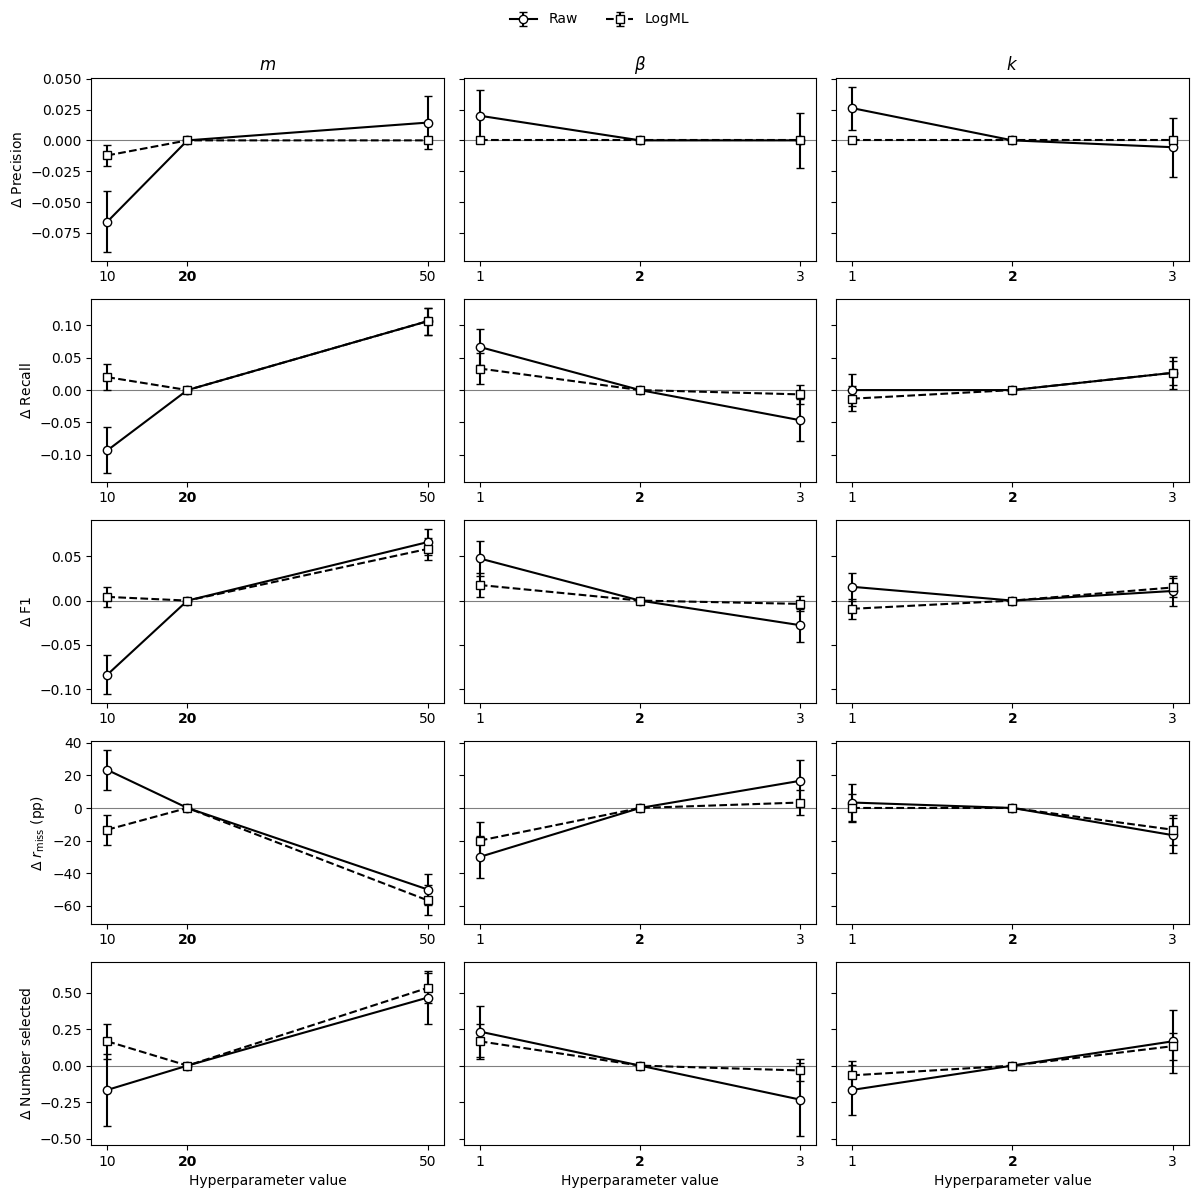

In [38]:
plot_paired_sensitivity(cont_paired, "global_se")

In [44]:
cont_sensitivity = aggregate_hyperparameter_sensitivity(cont_hyparam)
display_sensitivity_summary(cont_sensitivity, "global_se", output_path=output_path + "cont_sensitivity.csv")

,Parameter,Value,|Δ| Raw,|Δ| LogML,LogML − Raw
0,m,10,0.12 (0.02),0.03 (0.01),-0.08 (0.02)
1,m,50,0.08 (0.01),0.07 (0.01),-0.02 (0.01)
2,β,1,0.09 (0.01),0.05 (0.01),-0.04 (0.02)
3,β,3,0.07 (0.01),0.02 (0.01),-0.05 (0.02)
4,k,1,0.06 (0.01),0.03 (0.01),-0.03 (0.01)
5,k,3,0.06 (0.01),0.03 (0.01),-0.03 (0.01)


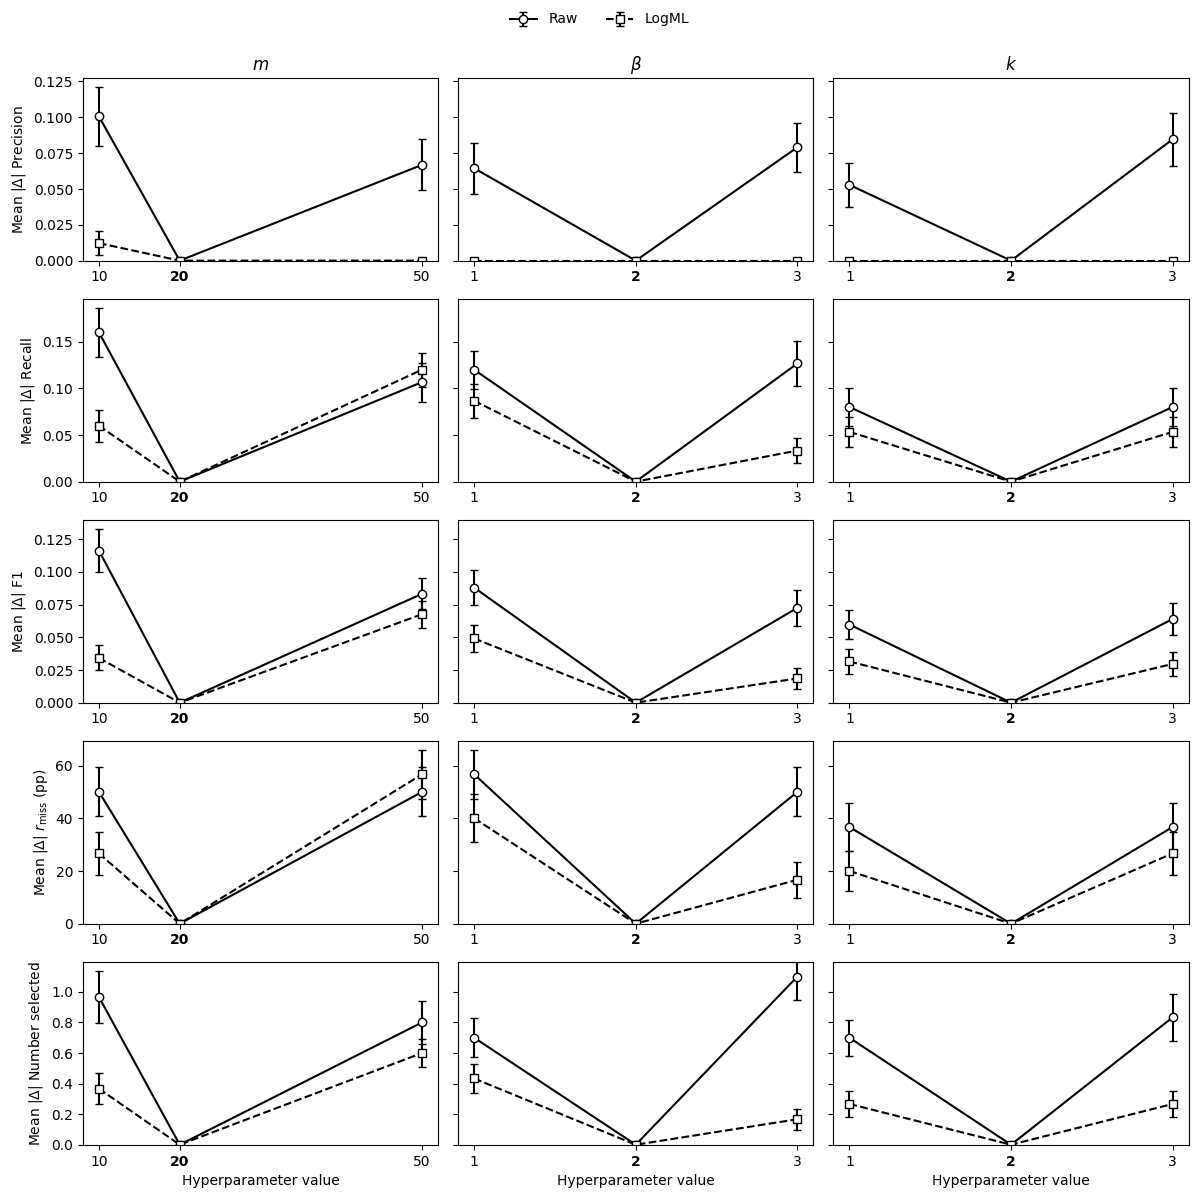

In [45]:
plot_hyperparameter_sensitivity(cont_sensitivity, "global_se")

In [46]:
mix_hyparam = pd.read_csv("results/hyperparams_results/cm2.csv")

In [47]:
mix_summary = aggregate_hyperparameter_results(mix_hyparam)
display_hyperparameter_summary(mix_summary, "global_se", output_path + "mix_summary.csv")

,Parameter,Value,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,m,10.000000,0.45 (0.05),0.49 (0.03),0.26 (0.02),0.53 (0.03),0.31 (0.03),0.50 (0.03),100%,97%
1,m,20.000000,0.46 (0.05),0.60 (0.04),0.26 (0.03),0.51 (0.03),0.31 (0.03),0.54 (0.03),100%,100%
2,m,50.000000,0.52 (0.04),0.66 (0.03),0.30 (0.02),0.49 (0.02),0.37 (0.03),0.55 (0.02),100%,100%
3,β,1.000000,0.53 (0.04),0.61 (0.04),0.24 (0.02),0.46 (0.03),0.32 (0.02),0.50 (0.03),100%,100%
4,β,2.000000,0.46 (0.05),0.60 (0.04),0.26 (0.03),0.51 (0.03),0.31 (0.03),0.54 (0.03),100%,100%
5,β,3.000000,0.46 (0.03),0.53 (0.03),0.31 (0.02),0.51 (0.03),0.36 (0.02),0.51 (0.03),100%,100%
6,k,1.000000,0.56 (0.04),0.59 (0.04),0.32 (0.02),0.49 (0.03),0.39 (0.03),0.53 (0.03),100%,100%
7,k,2.000000,0.46 (0.05),0.60 (0.04),0.26 (0.03),0.51 (0.03),0.31 (0.03),0.54 (0.03),100%,100%
8,k,3.000000,0.43 (0.05),0.58 (0.03),0.26 (0.03),0.50 (0.03),0.31 (0.03),0.52 (0.03),100%,100%


In [48]:
mix_paired = aggregate_paired_hyperparameter_results(mix_hyparam)
display_paired_summary(mix_paired, "global_se", output_path + "mix_paired.csv")

,Parameter,Value,Δ Precision Raw,Δ Precision LogML,Δ Recall Raw,Δ Recall LogML,Δ F1 Raw,Δ F1 LogML,Δ Selected Raw,Δ Selected LogML,Δ r_miss Raw,Δ r_miss LogML
0,m,10,-0.01 (0.06),-0.11 (0.03),+0.00 (0.03),+0.02 (0.03),+0.01 (0.04),-0.03 (0.03),-0.07 (0.44),+1.30 (0.31),+0.0 pp (0.0),-3.3 pp (3.3)
1,m,50,+0.06 (0.05),+0.06 (0.03),+0.04 (0.03),-0.02 (0.02),+0.06 (0.03),+0.01 (0.02),-0.20 (0.43),-0.50 (0.27),+0.0 pp (0.0),+0.0 pp (0.0)
2,β,1,+0.07 (0.06),+0.01 (0.04),-0.02 (0.02),-0.05 (0.02),+0.01 (0.03),-0.04 (0.02),-0.87 (0.36),-0.37 (0.32),+0.0 pp (0.0),+0.0 pp (0.0)
3,β,3,-0.00 (0.06),-0.07 (0.03),+0.05 (0.03),+0.00 (0.03),+0.05 (0.03),-0.03 (0.02),+0.40 (0.41),+0.60 (0.32),+0.0 pp (0.0),+0.0 pp (0.0)
4,k,1,+0.10 (0.06),-0.01 (0.03),+0.06 (0.03),-0.02 (0.02),+0.08 (0.03),-0.01 (0.02),-0.27 (0.38),-0.03 (0.28),+0.0 pp (0.0),+0.0 pp (0.0)
5,k,3,-0.03 (0.07),-0.02 (0.04),+0.00 (0.03),-0.01 (0.03),+0.00 (0.04),-0.01 (0.03),-0.27 (0.45),+0.17 (0.34),+0.0 pp (0.0),+0.0 pp (0.0)


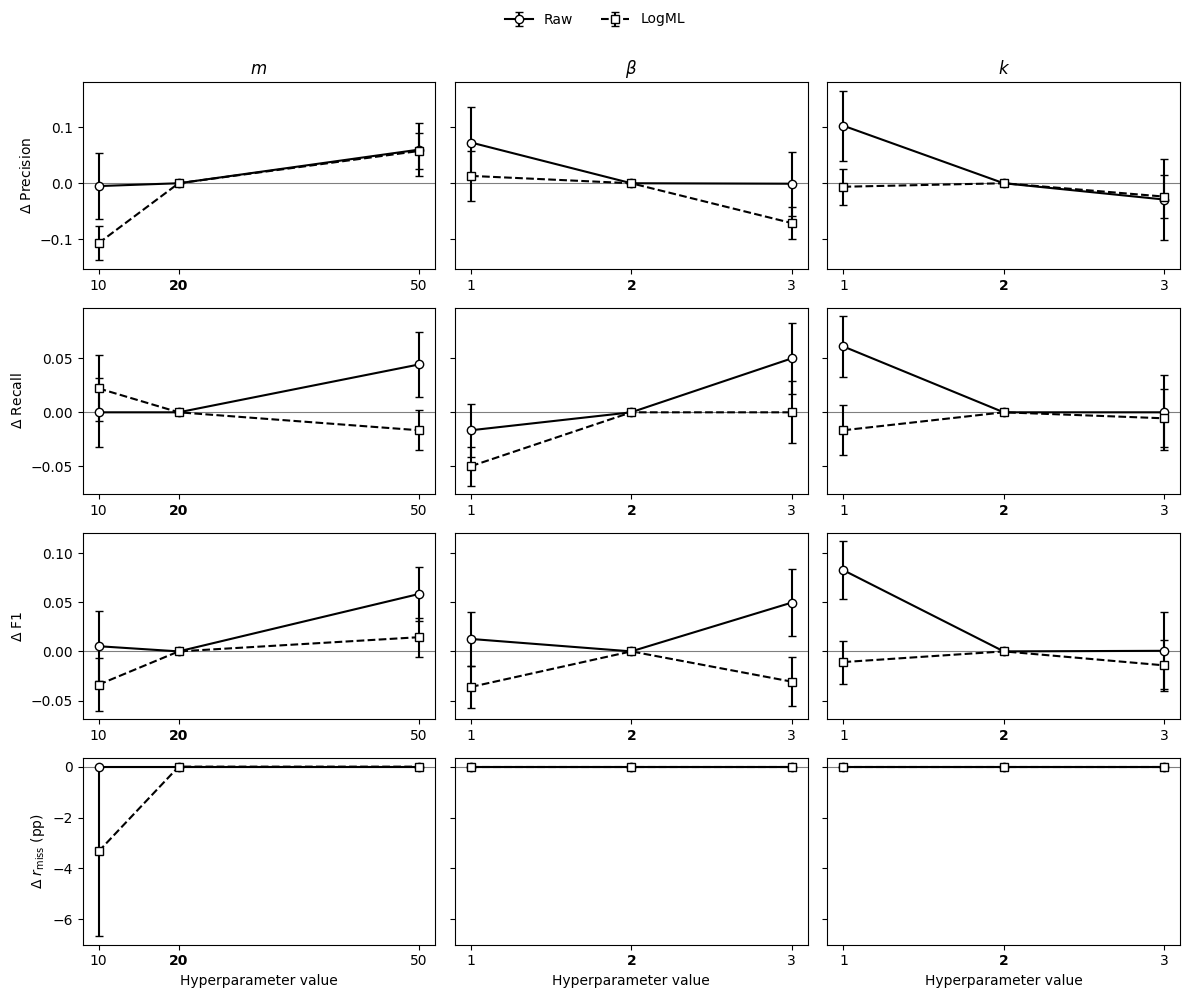

In [34]:
plot_paired_sensitivity(mix_paired, "global_se")

In [49]:
mix_sensitivity = aggregate_hyperparameter_sensitivity(mix_hyparam)
display_sensitivity_summary(mix_sensitivity, "global_se", output_path=output_path + "mix_sensitivity.csv")

,Parameter,Value,|Δ| Raw,|Δ| LogML,LogML − Raw
0,m,10,0.16 (0.02),0.11 (0.02),-0.06 (0.02)
1,m,50,0.12 (0.02),0.08 (0.01),-0.04 (0.02)
2,β,1,0.10 (0.02),0.09 (0.01),-0.01 (0.02)
3,β,3,0.16 (0.02),0.10 (0.02),-0.06 (0.02)
4,k,1,0.13 (0.02),0.10 (0.01),-0.04 (0.03)
5,k,3,0.17 (0.02),0.12 (0.01),-0.05 (0.02)


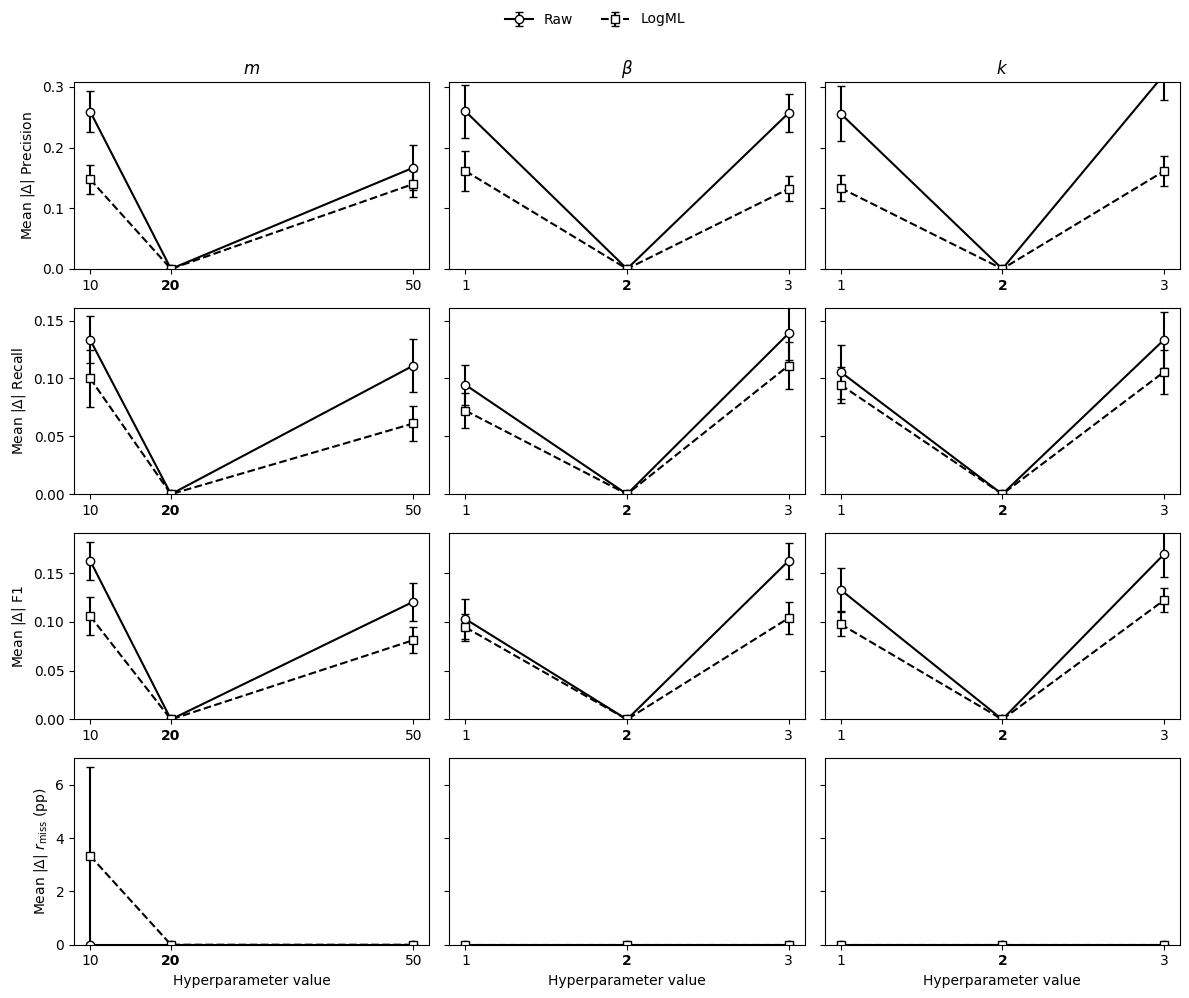

In [36]:
plot_hyperparameter_sensitivity(mix_sensitivity, "global_se")

In [26]:
bin_hyparam = pd.read_csv("results/hyperparams_results/bm1.csv")

In [27]:
bin_summary = aggregate_hyperparameter_results(bin_hyparam)
display_hyperparameter_summary(bin_summary, "global_se", output_path + "bin_summary.csv")

,Parameter,Value,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,m,10.000000,0.13 (0.05),0.30 (0.06),0.05 (0.02),0.13 (0.03),0.06 (0.02),0.18 (0.03),100%,100%
1,m,20.000000,0.11 (0.04),0.28 (0.06),0.05 (0.02),0.14 (0.03),0.07 (0.02),0.18 (0.04),100%,100%
2,m,50.000000,0.14 (0.05),0.39 (0.07),0.06 (0.02),0.15 (0.02),0.08 (0.03),0.21 (0.03),100%,100%
3,β,1.000000,0.11 (0.05),0.27 (0.06),0.04 (0.01),0.13 (0.03),0.05 (0.02),0.16 (0.04),100%,100%
4,β,2.000000,0.11 (0.04),0.28 (0.06),0.05 (0.02),0.14 (0.03),0.07 (0.02),0.18 (0.04),100%,100%
5,β,3.000000,0.15 (0.06),0.25 (0.06),0.05 (0.02),0.12 (0.03),0.07 (0.02),0.15 (0.04),100%,100%
6,k,1.000000,0.05 (0.03),0.25 (0.06),0.03 (0.01),0.12 (0.03),0.03 (0.02),0.15 (0.04),100%,100%
7,k,2.000000,0.11 (0.04),0.28 (0.06),0.05 (0.02),0.14 (0.03),0.07 (0.02),0.18 (0.04),100%,100%
8,k,3.000000,0.05 (0.03),0.28 (0.04),0.03 (0.02),0.15 (0.02),0.04 (0.02),0.19 (0.03),100%,100%


In [50]:
bin_paired = aggregate_paired_hyperparameter_results(bin_hyparam)
display_paired_summary(bin_paired, "global_se", output_path + "bin_paired.csv")

,Parameter,Value,Δ Precision Raw,Δ Precision LogML,Δ Recall Raw,Δ Recall LogML,Δ F1 Raw,Δ F1 LogML,Δ Selected Raw,Δ Selected LogML,Δ r_miss Raw,Δ r_miss LogML
0,m,10,+0.02 (0.06),+0.02 (0.09),-0.01 (0.02),-0.01 (0.04),-0.00 (0.03),-0.00 (0.05),-0.33 (0.29),-0.17 (0.29),+0.0 pp (0.0),+0.0 pp (0.0)
1,m,50,+0.03 (0.07),+0.11 (0.08),+0.01 (0.03),+0.01 (0.04),+0.02 (0.04),+0.03 (0.05),-0.20 (0.30),-0.37 (0.37),+0.0 pp (0.0),+0.0 pp (0.0)
2,β,1,-0.00 (0.07),-0.01 (0.08),-0.01 (0.03),-0.01 (0.04),-0.01 (0.03),-0.02 (0.04),-0.40 (0.36),+0.17 (0.37),+0.0 pp (0.0),+0.0 pp (0.0)
3,β,3,+0.04 (0.06),-0.03 (0.07),-0.01 (0.02),-0.02 (0.04),-0.00 (0.03),-0.03 (0.04),-0.17 (0.32),-0.17 (0.39),+0.0 pp (0.0),+0.0 pp (0.0)
4,k,1,-0.06 (0.05),-0.03 (0.07),-0.03 (0.02),-0.02 (0.04),-0.03 (0.03),-0.02 (0.05),-0.10 (0.27),-0.33 (0.37),+0.0 pp (0.0),+0.0 pp (0.0)
5,k,3,-0.06 (0.05),+0.01 (0.06),-0.02 (0.02),+0.01 (0.03),-0.03 (0.03),+0.01 (0.04),+0.10 (0.32),+0.07 (0.29),+0.0 pp (0.0),+0.0 pp (0.0)


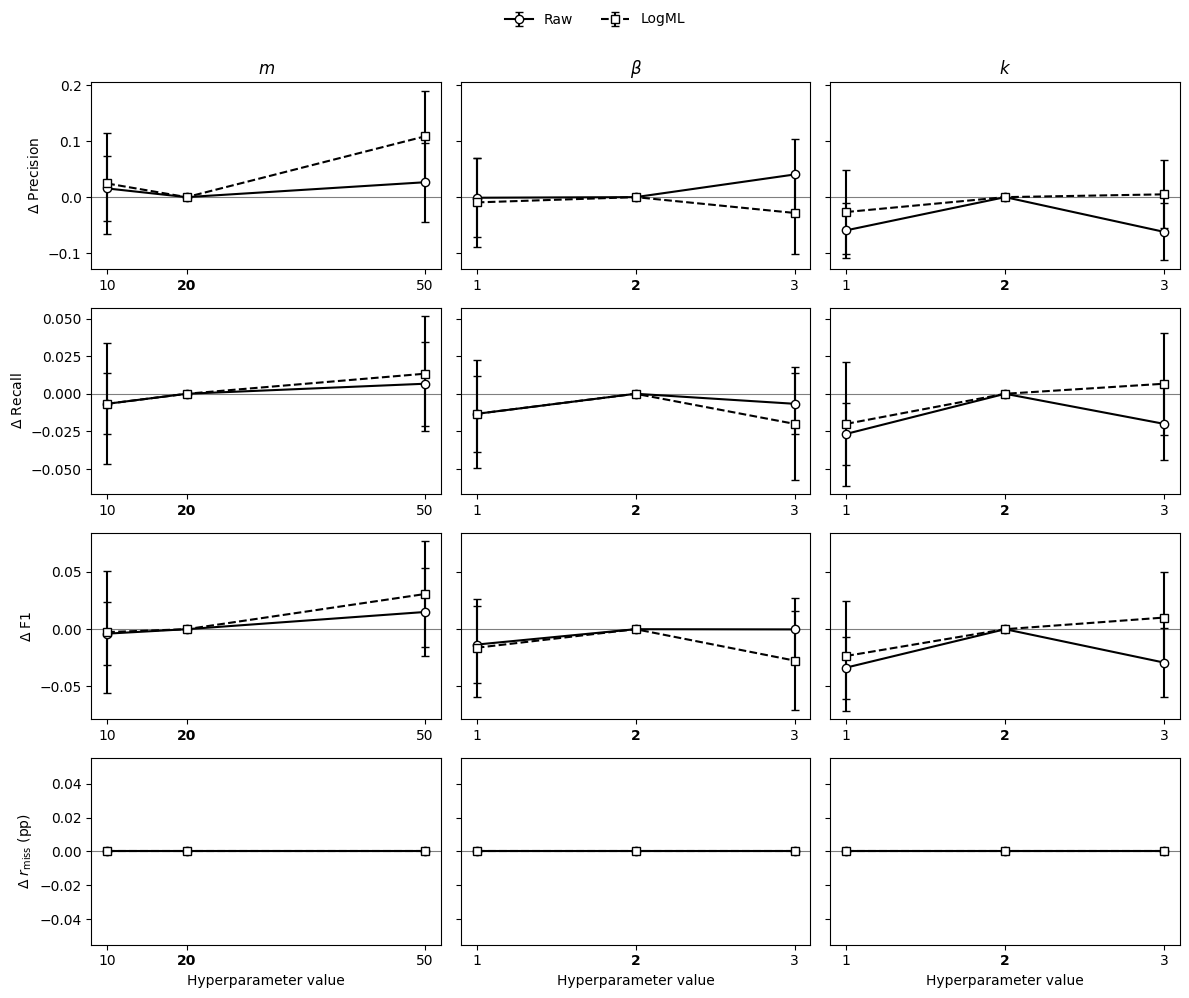

In [40]:
plot_paired_sensitivity(bin_paired, "global_se")

In [51]:
bin_sensitivity = aggregate_hyperparameter_sensitivity(bin_hyparam)
display_sensitivity_summary(bin_sensitivity, "global_se", output_path=output_path + "bin_sensitivity.csv")

,Parameter,Value,|Δ| Raw,|Δ| LogML,LogML − Raw
0,m,10,0.09 (0.02),0.24 (0.03),+0.15 (0.04)
1,m,50,0.12 (0.03),0.17 (0.03),+0.05 (0.04)
2,β,1,0.12 (0.03),0.17 (0.03),+0.04 (0.04)
3,β,3,0.08 (0.02),0.14 (0.03),+0.06 (0.03)
4,k,1,0.09 (0.02),0.19 (0.03),+0.11 (0.04)
5,k,3,0.09 (0.03),0.16 (0.03),+0.07 (0.03)


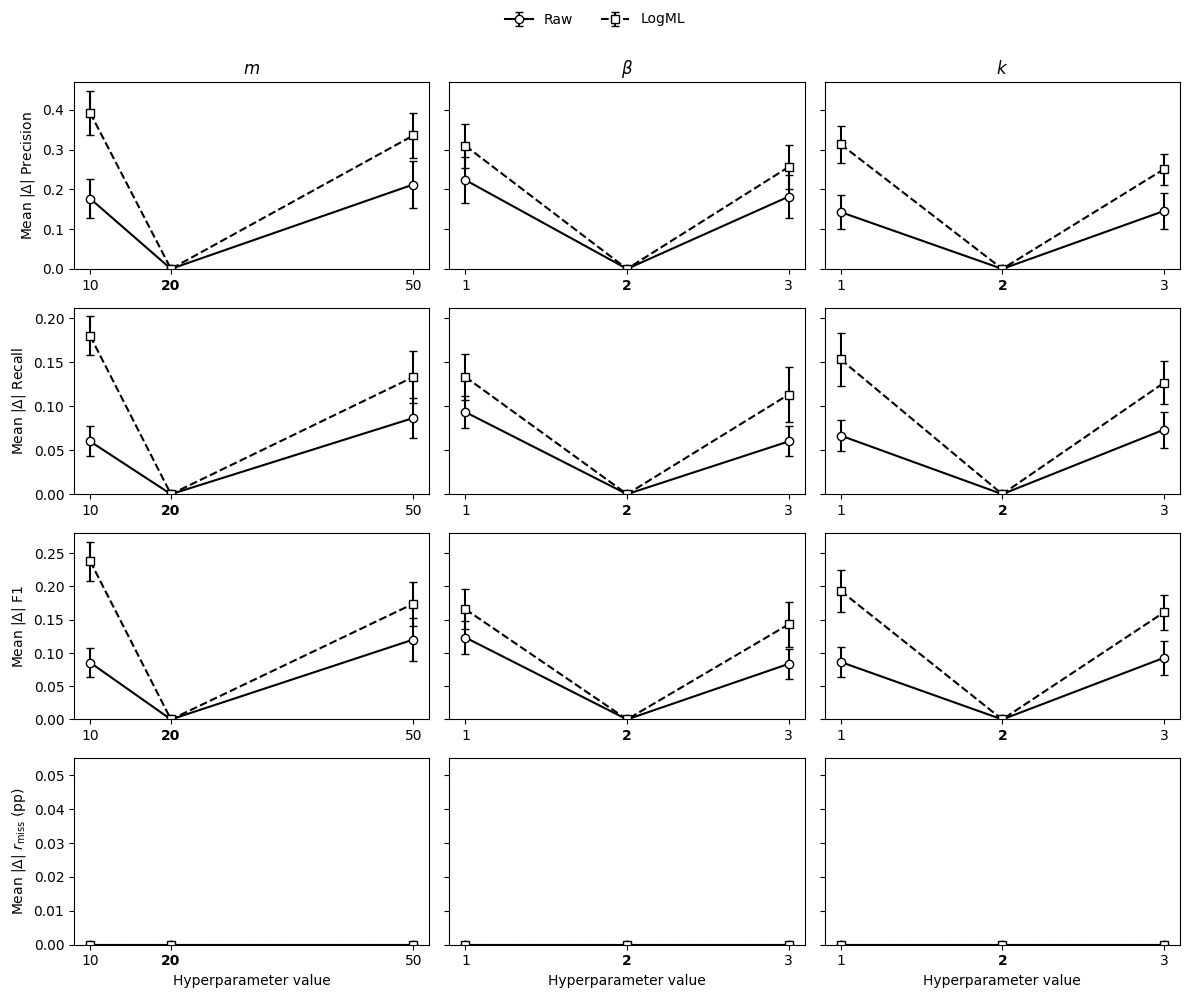

In [42]:
plot_hyperparameter_sensitivity(bin_sensitivity, "global_se")